Notebook de ejemplo: Perceptrón básico en Python
Casos de prueba (entradas):


,horas_estudio,horas_sueno
0,0,1
1,1,3
2,2,2
3,3,1
4,4,2
5,5,3
6,2,0
7,1,1
8,3,2
9,4,4


Resultados configuración 1 (w = [0.8, 0.2], b = -2.0):


,horas_estudio,horas_sueno,z,salida_y
0,0,1,-1.8,0
1,1,3,-0.6,0
2,2,2,0.0,1
3,3,1,0.6,1
4,4,2,1.6,1
5,5,3,2.6,1
6,2,0,-0.4,0
7,1,1,-1.0,0
8,3,2,0.8,1
9,4,4,2.0,1


Resultados configuración 2 (w = [1.0, 0.1], b = -3.0):


,horas_estudio,horas_sueno,z,salida_y
0,0,1,-2.9,0
1,1,3,-1.7,0
2,2,2,-0.8,0
3,3,1,0.1,1
4,4,2,1.2,1
5,5,3,2.3,1
6,2,0,-1.0,0
7,1,1,-1.9,0
8,3,2,0.2,1
9,4,4,1.4,1


Comparación de salidas entre configuración 1 y 2:


,horas_estudio,horas_sueno,z_conf1,y_conf1,z_conf2,y_conf2
0,0,1,-1.8,0,-2.9,0
1,1,3,-0.6,0,-1.7,0
2,2,2,0.0,1,-0.8,0
3,3,1,0.6,1,0.1,1
4,4,2,1.6,1,1.2,1
5,5,3,2.6,1,2.3,1
6,2,0,-0.4,0,-1.0,0
7,1,1,-1.0,0,-1.9,0
8,3,2,0.8,1,0.2,1
9,4,4,2.0,1,1.4,1


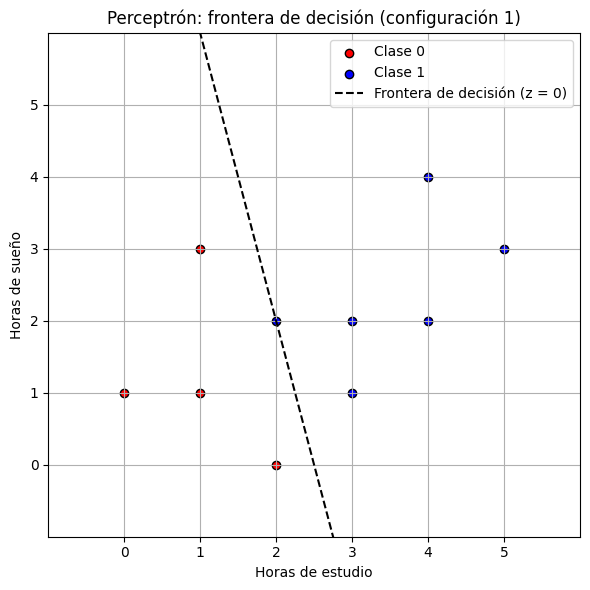

In [4]:
# =====================================
# BLOQUE 1: IMPORTS Y CONTEXTO
# =====================================

import numpy as np
import pandas as pd

print("Notebook de ejemplo: Perceptrón básico en Python")

# =====================================
# BLOQUE 2: DEFINICIÓN DEL PERCEPTRÓN
# =====================================

def perceptron_predict(X, weights, bias):
    """
    X: matriz de entrada (n_ejemplos x n_features)
    weights: vector de pesos (n_features,)
    bias: escalar (b)

    Retorna:
      z: puntaje lineal (np.dot(X, w) + b)
      y_hat: salida binaria (0 o 1) usando función escalón
    """
    # 1) Cálculo del puntaje z = w1*x1 + w2*x2 + ... + b
    z = np.dot(X, weights) + bias

    # 2) Decisión de salida: si z >= 0 → 1, si z < 0 → 0
    y_hat = (z >= 0).astype(int)
    return z, y_hat

# =====================================
# BLOQUE 3: DATOS DE PRUEBA
# =====================================

# Creamos un DataFrame con varios casos de prueba
test_data = pd.DataFrame({
    'horas_estudio': [0, 1, 2, 3, 4, 5, 2, 1, 3, 4],
    'horas_sueno':   [1, 3, 2, 1, 2, 3, 0, 1, 2, 4],
})

print("Casos de prueba (entradas):")
display(test_data)


# ==========================================
# BLOQUE 4: CONFIGURACIÓN 1 DE PESOS Y BIAS
# ==========================================

weights_1 = np.array([0.8, 0.2])  # w1 = 0.8 (estudio), w2 = 0.2 (sueño)
bias_1 = -2.0                     # b = -2.0 → umbral relativamente exigente

X = test_data[['horas_estudio', 'horas_sueno']].values

z1, y1 = perceptron_predict(X, weights_1, bias_1)

resultados_1 = test_data.copy()
resultados_1['z'] = z1
resultados_1['salida_y'] = y1

print("Resultados configuración 1 (w = [0.8, 0.2], b = -2.0):")
display(resultados_1)

# Guardamos por si quieres usarlo fuera del notebook
resultados_1.to_csv("perceptron_resultados_config1.csv", index=False)


# ==========================================
# BLOQUE 5: CONFIGURACIÓN 2 DE PESOS Y BIAS
# ==========================================

weights_2 = np.array([1.0, 0.1])  # Estudio pesa más, sueño casi no importa
bias_2 = -3.0                     # Umbral aún más exigente

z2, y2 = perceptron_predict(X, weights_2, bias_2)

resultados_2 = test_data.copy()
resultados_2['z'] = z2
resultados_2['salida_y'] = y2

print("Resultados configuración 2 (w = [1.0, 0.1], b = -3.0):")
display(resultados_2)

# Guardamos resultados
resultados_2.to_csv("perceptron_resultados_config2.csv", index=False)


# =====================================
# BLOQUE 6: TABLA COMPARATIVA
# =====================================

comparacion = test_data.copy()
comparacion['z_conf1'] = z1
comparacion['y_conf1'] = y1
comparacion['z_conf2'] = z2
comparacion['y_conf2'] = y2

print("Comparación de salidas entre configuración 1 y 2:")
display(comparacion)



# ==========================================
# BLOQUE 7: GRÁFICA FRONTERA DE DECISIÓN
# (configuración 1)
# ==========================================

import matplotlib.pyplot as plt

# Volvemos a usar:
# test_data, w1 = [0.8, 0.2], b1 = -2.0

w1 = np.array([0.8, 0.2])
b1 = -2.0

X = test_data[['horas_estudio', 'horas_sueno']].values
z = X @ w1 + b1
y = (z >= 0).astype(int)

# Recta de frontera de decisión:
# z = 0 => w1*x1 + w2*x2 + b = 0
# => x2 = -(w1*x1 + b) / w2
x1_line = np.linspace(-1, 6, 100)
x2_line = -(w1[0]*x1_line + b1) / w1[1]

plt.figure(figsize=(6, 6))

# Puntos clasificados como 0 (rojo) y 1 (azul)
plt.scatter(
    test_data['horas_estudio'][y == 0],
    test_data['horas_sueno'][y == 0],
    c='red', label='Clase 0', edgecolor='k'
)
plt.scatter(
    test_data['horas_estudio'][y == 1],
    test_data['horas_sueno'][y == 1],
    c='blue', label='Clase 1', edgecolor='k'
)

# Línea de decisión
plt.plot(x1_line, x2_line, 'k--', label='Frontera de decisión (z = 0)')

plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.xticks(range(0, 6))
plt.yticks(range(0, 6))
plt.xlabel('Horas de estudio')
plt.ylabel('Horas de sueño')
plt.title('Perceptrón: frontera de decisión (configuración 1)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


